In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
from datetime import datetime

In [7]:
files = sorted(glob.glob('mufluxes/combined_muflux_*.npy'))

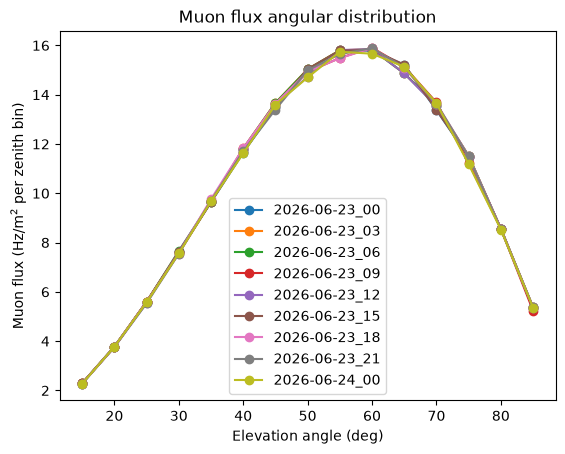

In [10]:
for fname in files:
    data = np.load(fname)
    angles, flux = data[0], data[1]

    plt.plot(angles, flux, marker='o', label=fname[-20:-7])
plt.xlabel('Elevation angle (deg)')
plt.ylabel('Muon flux (Hz/m$^2$ per zenith bin)')
plt.legend()
plt.title(f'Muon flux angular distribution')
plt.show()

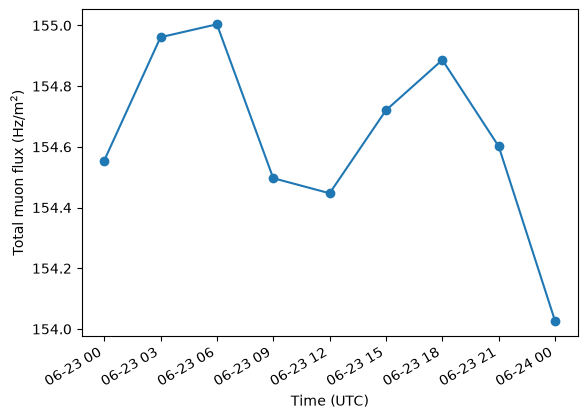

In [18]:
times, totals = [], []
for f in files:
    ts = f[-20:-4]
    times.append(datetime.strptime(ts, '%Y-%m-%d_%HUTC'))
    totals.append(np.load(f)[1].sum())

plt.plot(times, totals, marker='o')
plt.xlabel('Time (UTC)')
plt.ylabel('Total muon flux (Hz/m$^2$)')
# plt.ylim(153, 156)
plt.gcf().autofmt_xdate()
plt.show()